In [10]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import datetime
import itertools
import matplotlib.dates as mdates
import pandas as pd

In [11]:
import gc
import tensorflow as tf

tf.keras.backend.clear_session()
gc.collect()

keras.backend.clear_session()

In [12]:
import os

# Data path from AGENTS.md
data_folder = "/home/haseebumer/content/data/extracted/"

# !change model name for different models!
model_name = "CNN_nowcast_2017_2019_data"
output_folder = os.path.join(
    "model_output", model_name
)

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# File paths for extracted datasets
trainval_images_path = os.path.join(data_folder, "trainval_images_log.npy")
trainval_pv_path = os.path.join(data_folder, "trainval_pv_log.npy")
test_images_path = os.path.join(data_folder, "test_images_log.npy")
test_pv_path = os.path.join(data_folder, "test_pv_log.npy")

times_trainval_path = os.path.join(data_folder, "times_trainval.npy")
times_test_path = os.path.join(data_folder, "times_test.npy")

print("data_folder:", data_folder)
print("output_folder:", output_folder)
print("trainval_images:", trainval_images_path)
print("trainval_pv:", trainval_pv_path)

data_folder: /home/haseebumer/content/data/extracted/
output_folder: model_output/CNN_nowcast_2017_2019_data
trainval_images: /home/haseebumer/content/data/extracted/trainval_images_log.npy
trainval_pv: /home/haseebumer/content/data/extracted/trainval_pv_log.npy


## Data Loading & Training


In [13]:
# Model & Training parameters
SEQ_LEN = 16  # Benchmark sequence alignment length (matches LSTM / CNN-LSTM baselines)
# 0 for nowcast (predicting contemporaneous PV from sky camera image), or >0 for future horizon
FORECAST_HORIZON = 0
NUM_FOLDS = 10  # 10-fold cross validation
NUM_EPOCHS = 200  # Max epochs (EarlyStopping will halt earlier)
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
PATIENCE = 10  # Early stopping patience

In [14]:
# Memory-map large image files to prevent Colab RAM overflow (Best Practice)
trainval_images = np.load(trainval_images_path, mmap_mode="r")
test_images = np.load(test_images_path, mmap_mode="r")

trainval_pv = np.load(trainval_pv_path).astype(np.float32)
test_pv = np.load(test_pv_path).astype(np.float32)

times_trainval = np.load(times_trainval_path, allow_pickle=True)
times_test = np.load(times_test_path, allow_pickle=True)

print(
    f"trainval_images shape: {trainval_images.shape} | dtype: {trainval_images.dtype}"
)
print(f"test_images shape:     {test_images.shape} | dtype: {test_images.dtype}")
print(f"trainval_pv shape:     {trainval_pv.shape} | times: {times_trainval.shape}")
print(f"test_pv shape:         {test_pv.shape} | times: {times_test.shape}")

trainval_images shape: (349372, 64, 64, 3) | dtype: uint8
test_images shape:     (14003, 64, 64, 3) | dtype: uint8
trainval_pv shape:     (349372,) | times: (349372,)
test_pv shape:         (14003,) | times: (14003,)


In [15]:
class ImageDataset:
    """
    Zero-copy image dataset wrapper around memory-mapped sky camera images.
    Enables streaming batches on-demand from disk without blowing up Colab RAM,
    while exposing standard NumPy-like shape, length, and batch-indexing.
    """

    def __init__(self, images_mmap, indices):
        self.images = images_mmap
        self.indices = np.array(indices, dtype=np.int32)
        self.shape = (len(indices),) + images_mmap.shape[1:]
        self.dtype = images_mmap.dtype

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        if isinstance(idx, (int, np.integer)):
            return self.images[self.indices[idx]]
        return self.images[self.indices[idx]]

    def __repr__(self):
        return f"ImageDataset(num_samples={len(self):,}, shape={self.shape}, dtype={self.dtype})"


def create_day_aware_sequences(
    pv_array, times_array, images_array, seq_len=16, horizon=0
):
    """
    Constructs (X, y, sequence_dates, sequence_times) for CNN nowcasting:
    - X: contemporaneous sky camera images at time t
    - y: contemporaneous solar PV power output at time t
    Ensures that no sequence crosses overnight boundaries or distinct dates,
    matching the exact temporal alignment of 01-lstm-baseline.ipynb.
    """

    dates = np.array(
        [
            (
                t.date()
                if isinstance(t, (datetime.datetime, datetime.date))
                else pd.to_datetime(t).date()
            )
            for t in times_array
        ]
    )

    unique_dates = np.unique(dates)

    y_list = []
    valid_dates_list = []
    valid_times_list = []
    img_indices_list = []

    for d in unique_dates:
        day_indices = np.where(dates == d)[0]
        num_day_points = len(day_indices)

        # Minimum required points for sequence + target
        if num_day_points <= seq_len + horizon:
            continue

        day_pv = pv_array[day_indices]
        day_times = times_array[day_indices]

        for i in range(seq_len, num_day_points - horizon):
            target_idx = i + horizon
            seq_y = day_pv[target_idx]

            y_list.append(seq_y)
            valid_dates_list.append(d)
            valid_times_list.append(day_times[target_idx])
            img_indices_list.append(day_indices[target_idx])

    X = ImageDataset(images_array, img_indices_list)
    y = np.array(y_list, dtype=np.float32)  # Shape: (N,)

    valid_dates = np.array(valid_dates_list)
    valid_times = np.array(valid_times_list)

    return X, y, valid_dates, valid_times


X_trainval, y_trainval, dates_trainval_seq, times_trainval_seq = (
    create_day_aware_sequences(
        trainval_pv,
        times_trainval,
        images_array=trainval_images,
        seq_len=SEQ_LEN,
        horizon=FORECAST_HORIZON,
    )
)

X_test, y_test, dates_test_seq, times_test_seq = create_day_aware_sequences(
    test_pv,
    times_test,
    images_array=test_images,
    seq_len=SEQ_LEN,
    horizon=FORECAST_HORIZON,
)

print(f"X_trainval shape: {X_trainval.shape}, " f"y_trainval shape: {y_trainval.shape}")
print(f"X_test shape:     {X_test.shape}, " f"y_test shape:     {y_test.shape}")

X_trainval shape: (341420, 64, 64, 3), y_trainval shape: (341420,)
X_test shape:     (13683, 64, 64, 3), y_test shape:     (13683,)


In [16]:
def shuffle_unique_dates(dates_array, seed=1):
    """
    Shuffles the unique CALENDAR DATES (not sample indices).
    Fold boundaries are cut on this array, so folds are day-based.
    """
    unique_dates = np.unique(dates_array)
    rng = np.random.RandomState(seed)
    rng.shuffle(unique_dates)
    return unique_dates


def cv_split_indices(dates_array_full, shuffled_unique_dates, fold_index, num_folds=10):
    """
    Splits by whole days: the fold_index-th slice of shuffled_unique_dates
    becomes the validation dates. Every sample whose date falls in that
    slice goes to validation; everything else goes to training.
    No calendar day is ever split across train and validation.
    """
    num_days = len(shuffled_unique_dates)
    val_start = int(fold_index / num_folds * num_days)
    val_end = int((fold_index + 1) / num_folds * num_days)

    val_dates = set(shuffled_unique_dates[val_start:val_end])

    val_mask = np.isin(dates_array_full, list(val_dates))
    train_mask = ~val_mask

    all_indices = np.arange(len(dates_array_full))
    train_idx = all_indices[train_mask]
    val_idx = all_indices[val_mask]

    rng = np.random.RandomState(fold_index)
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)

    return train_idx, val_idx


def build_tf_dataset(X, y, indices, batch_size=256, is_training=True):
    """
    Builds an optimized streaming tf.data.Dataset pipeline.
    Streams image batches on-demand directly from memory-mapped disk storage,
    preventing RAM exhaustion (OOM) and kernel crashes.
    Uses prefetching and AUTOTUNE for maximum GPU training throughput.
    """
    sub_indices = np.array(indices)
    num_samples = len(sub_indices)
    num_batches = int(np.ceil(num_samples / batch_size))

    def generator():
        curr_idx = sub_indices.copy()
        if is_training:
            np.random.shuffle(curr_idx)
        for start in range(0, num_samples, batch_size):
            b_idx = curr_idx[start : start + batch_size]
            b_img = X[b_idx]
            b_y = y[b_idx]
            yield b_img, b_y

    output_signature = (
        tf.TensorSpec(shape=(None, 64, 64, 3), dtype=tf.uint8),
        tf.TensorSpec(shape=(None,), dtype=tf.float32),
    )

    ds = tf.data.Dataset.from_generator(generator, output_signature=output_signature)
    ds = ds.apply(tf.data.experimental.assert_cardinality(num_batches))
    return ds.prefetch(tf.data.AUTOTUNE)

In [17]:
def build_cnn_model(
    input_shape=(64, 64, 3),
    filters=(32, 64, 128),
    dense_units=128,
    name="CNN_Solar_Nowcast",
):
    """
    Builds a 2D CNN regression model for solar PV nowcasting directly from sky camera images.

    Model Architecture:
    1. Input: Contemporaneous sky camera image (64, 64, 3) in uint8 format.
    2. Rescaling: Normalizes pixel intensities [0, 255] to [0.0, 1.0] on-GPU.
    3. Convolutional Backbone: 3 Conv2D blocks (32, 64, 128 filters, 3x3 kernels, same padding,
       BatchNormalization, ReLU activation, 2x2 MaxPooling, and Dropout).
    4. Spatial Pooling: GlobalAveragePooling2D aggregates global sky / cloud spatial features.
    5. Regression Head: Dense layer (128 units, ReLU), Dropout, and a final linear Dense unit
       to output the predicted PV power generation in kW.
    """
    inputs = keras.Input(shape=input_shape, name="sky_image_input")

    # Efficient GPU rescaling from uint8 [0, 255] to float32 [0.0, 1.0]
    x = keras.layers.Rescaling(1.0 / 255.0, name="rescaling")(inputs)

    # Convolutional feature extraction blocks
    for i, f in enumerate(filters):
        x = keras.layers.Conv2D(
            filters=f,
            kernel_size=(3, 3),
            padding="same",
            activation="relu",
            name=f"conv_{i + 1}",
        )(x)
        x = keras.layers.BatchNormalization(name=f"bn_{i + 1}")(x)
        x = keras.layers.MaxPooling2D(pool_size=(2, 2), name=f"pool_{i + 1}")(x)

    # Spatial aggregation into feature vector
    x = keras.layers.GlobalAveragePooling2D(name="gap")(x)

    # Fully-connected projection head
    x = keras.layers.Dense(dense_units, activation="relu", name="dense_1")(x)

    outputs = keras.layers.Dense(units=1, activation="linear", name="pv_prediction")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name=name)

    return model


sample_model = build_cnn_model(input_shape=(64, 64, 3))

sample_model.summary()

I0000 00:00:1788851124.735686  113153 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 8101 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:23:00.0, compute capability: 8.6
I0000 00:00:1788851124.736950  113153 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 7695 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:2d:00.0, compute capability: 8.6


Model: "CNN_Solar_Nowcast"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sky_image_input (InputLayer)    │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_3 (MaxPooling2D)           │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pv_prediction (Dense)           │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

In [18]:
# TensorBoard log directory
tensorboard_root = os.path.join(output_folder, "tensorboard_logs")
os.makedirs(tensorboard_root, exist_ok=True)

In [19]:
shuffled_unique_dates = shuffle_unique_dates(dates_trainval_seq, seed=1)

# --- Resume support: load existing history if this cell was run before ---
history_paths = {
    "train_loss": os.path.join(output_folder, "train_loss_hist.npy"),
    "val_loss": os.path.join(output_folder, "val_loss_hist.npy"),
    "train_mae": os.path.join(output_folder, "train_mae_hist.npy"),
    "val_mae": os.path.join(output_folder, "val_mae_hist.npy"),
}

if all(os.path.exists(p) for p in history_paths.values()):
    train_loss_hist = list(np.load(history_paths["train_loss"], allow_pickle=True))
    val_loss_hist = list(np.load(history_paths["val_loss"], allow_pickle=True))
    train_mae_hist = list(np.load(history_paths["train_mae"], allow_pickle=True))
    val_mae_hist = list(np.load(history_paths["val_mae"], allow_pickle=True))
    print(
        f"Resuming: found existing history for {len(train_loss_hist)} completed fold(s)."
    )
else:
    train_loss_hist = []
    val_loss_hist = []
    train_mae_hist = []
    val_mae_hist = []

# A fold counts as "done" only if BOTH its checkpoint exists AND its history was
# already recorded above (checkpoint alone isn't proof the fold finished/saved).
start_fold = len(train_loss_hist)

if start_fold >= NUM_FOLDS:
    print(f"All {NUM_FOLDS} folds already completed. Nothing to train.")

for fold in range(start_fold, NUM_FOLDS):

    print(f" Repetition / Fold {fold + 1} of {NUM_FOLDS} ")

    keras.backend.clear_session()

    model = build_cnn_model(input_shape=(64, 64, 3))

    optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)

    model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])

    save_directory = os.path.join(output_folder, f"repetition_{fold + 1}")
    os.makedirs(save_directory, exist_ok=True)

    checkpoint_path = os.path.join(
        save_directory, f"best_model_repetition_{fold + 1}.h5"
    )

    # Splits & Datasets (day-level split — no day appears in both train and val)

    idx_train, idx_val = cv_split_indices(
        dates_trainval_seq, shuffled_unique_dates, fold, NUM_FOLDS
    )

    ds_train = build_tf_dataset(
        X_trainval, y_trainval, idx_train, batch_size=BATCH_SIZE, is_training=True
    )

    ds_val = build_tf_dataset(
        X_trainval, y_trainval, idx_val, batch_size=BATCH_SIZE, is_training=False
    )

    # Callbacks

    earlystop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1,
    )

    checkpoint = keras.callbacks.ModelCheckpoint(
        checkpoint_path, monitor="val_loss", mode="min", save_best_only=True, verbose=1
    )

    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
    )

    # TensorBoard
    tensorboard_log_dir = os.path.join(tensorboard_root, f"fold_{fold + 1}")

    tensorboard = keras.callbacks.TensorBoard(
        log_dir=tensorboard_log_dir,
        histogram_freq=1,
        update_freq="epoch",
        write_graph=True,
    )

    # Training

    history = model.fit(
        ds_train,
        epochs=NUM_EPOCHS,
        validation_data=ds_val,
        callbacks=[earlystop, checkpoint, reduce_lr, tensorboard],
        verbose=1,
    )

    # Store training history

    train_loss_hist.append(history.history["loss"])
    val_loss_hist.append(history.history["val_loss"])
    train_mae_hist.append(history.history["mae"])
    val_mae_hist.append(history.history["val_mae"])

    # Save history arrays (checkpointed after EVERY fold, so a crash mid-run
    # only loses the in-progress fold, not previously completed ones)

    np.save(
        os.path.join(output_folder, "train_loss_hist.npy"),
        np.array(train_loss_hist, dtype=object),
    )

    np.save(
        os.path.join(output_folder, "val_loss_hist.npy"),
        np.array(val_loss_hist, dtype=object),
    )

    np.save(
        os.path.join(output_folder, "train_mae_hist.npy"),
        np.array(train_mae_hist, dtype=object),
    )

    np.save(
        os.path.join(output_folder, "val_mae_hist.npy"),
        np.array(val_mae_hist, dtype=object),
    )

    print(f"Fold {fold + 1} complete and saved.")

 Repetition / Fold 1 of 10 


/home/haseebumer/skippd-solar-forecasting/aienv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/200


I0000 00:00:1788851126.218954  113153 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1788851127.467380  118055 service.cc:153] XLA service 0x771d0003afc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788851127.467431  118055 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3080, Compute Capability 8.6 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1788851127.467441  118055 service.cc:161]   StreamExecutor [1]: NVIDIA GeForce RTX 3080, Compute Capability 8.6 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1788851127.542052  118055 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1788851127.789838  118055 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1788851127.812972  118055 dot_merger.cc:481] Merging Dots in computation: a_inference_on

   9/1209 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 155.0570 - mae: 10.4034

...


Epoch 6: finished saving model to model_output/CNN_nowcast_2017_2019_data/repetition_10/best_model_repetition_10.h5
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 1.9815 - mae: 0.8264 - val_loss: 2.4840 - val_mae: 0.9001 - learning_rate: 0.0010
Epoch 7/200
1192/1196 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.8682 - mae: 0.7971
Epoch 7: val_loss did not improve from 2.48398
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 1.8679 - mae: 0.7970 - val_loss: 2.6768 - val_mae: 0.9008 - learning_rate: 0.0010
Epoch 8/200
1193/1196 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.7715 - mae: 0.7823
Epoch 8: val_loss did not improve from 2.48398
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 1.7725 - mae: 0.7824 - val_loss: 2.5351 - val_mae: 0.9523 - learning_rate: 0.0010
Epoch 9/200
1192/1196 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.6322 - mae: 0.7466
Epoch 9: val_loss did not improve from 2.48398

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1196/


Epoch 12: finished saving model to model_output/CNN_nowcast_2017_2019_data/repetition_10/best_model_repetition_10.h5
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 1.1579 - mae: 0.6203 - val_loss: 2.4796 - val_mae: 0.8426 - learning_rate: 5.0000e-04
Epoch 13/200
1193/1196 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.0921 - mae: 0.6082
Epoch 13: val_loss did not improve from 2.47957
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 1.0927 - mae: 0.6083 - val_loss: 2.6550 - val_mae: 0.8260 - learning_rate: 5.0000e-04
Epoch 14/200
1193/1196 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.0275 - mae: 0.5944
Epoch 14: val_loss did not improve from 2.47957
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 1.0273 - mae: 0.5944 - val_loss: 2.6373 - val_mae: 0.8423 - learning_rate: 5.0000e-04
Epoch 15/200
1193/1196 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9709 - mae: 0.5784
Epoch 15: val_loss did not improve from 2.47957

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.000250


Epoch 19: finished saving model to model_output/CNN_nowcast_2017_2019_data/repetition_10/best_model_repetition_10.h5
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 0.6436 - mae: 0.4747 - val_loss: 2.4326 - val_mae: 0.7686 - learning_rate: 1.2500e-04
Epoch 20/200
1193/1196 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.6256 - mae: 0.4698
Epoch 20: val_loss improved from 2.43260 to 2.36975, saving model to model_output/CNN_nowcast_2017_2019_data/repetition_10/best_model_repetition_10.h5



Epoch 20: finished saving model to model_output/CNN_nowcast_2017_2019_data/repetition_10/best_model_repetition_10.h5
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 0.6256 - mae: 0.4698 - val_loss: 2.3698 - val_mae: 0.7609 - learning_rate: 1.2500e-04
Epoch 21/200
1193/1196 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.6080 - mae: 0.4644
Epoch 21: val_loss did not improve from 2.36975
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 0.6077 - mae: 0.4644 - val_loss: 2.4469 - val_mae: 0.7739 - learning_rate: 1.2500e-04
Epoch 22/200
1193/1196 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5950 - mae: 0.4618
Epoch 22: val_loss did not improve from 2.36975
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 0.5951 - mae: 0.4618 - val_loss: 2.7235 - val_mae: 0.8360 - learning_rate: 1.2500e-04
Epoch 23/200
1193/1196 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5796 - mae: 0.4566
Epoch 23: val_loss did not improve from 2.36975

Epoch 23: ReduceLROnPlateau reducing learning rate to 6.250000


Epoch 26: finished saving model to model_output/CNN_nowcast_2017_2019_data/repetition_10/best_model_repetition_10.h5
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 0.5205 - mae: 0.4355 - val_loss: 2.3435 - val_mae: 0.7493 - learning_rate: 6.2500e-05
Epoch 27/200
1193/1196 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5162 - mae: 0.4341
Epoch 27: val_loss did not improve from 2.34351
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 0.5162 - mae: 0.4342 - val_loss: 2.4498 - val_mae: 0.7521 - learning_rate: 6.2500e-05
Epoch 28/200
1193/1196 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5072 - mae: 0.4308
Epoch 28: val_loss did not improve from 2.34351
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 0.5073 - mae: 0.4309 - val_loss: 2.4161 - val_mae: 0.7646 - learning_rate: 6.2500e-05
Epoch 29/200
1193/1196 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5008 - mae: 0.4296
Epoch 29: val_loss did not improve from 2.34351

Epoch 29: ReduceLROnPlateau reducing learning rate to 3.125000

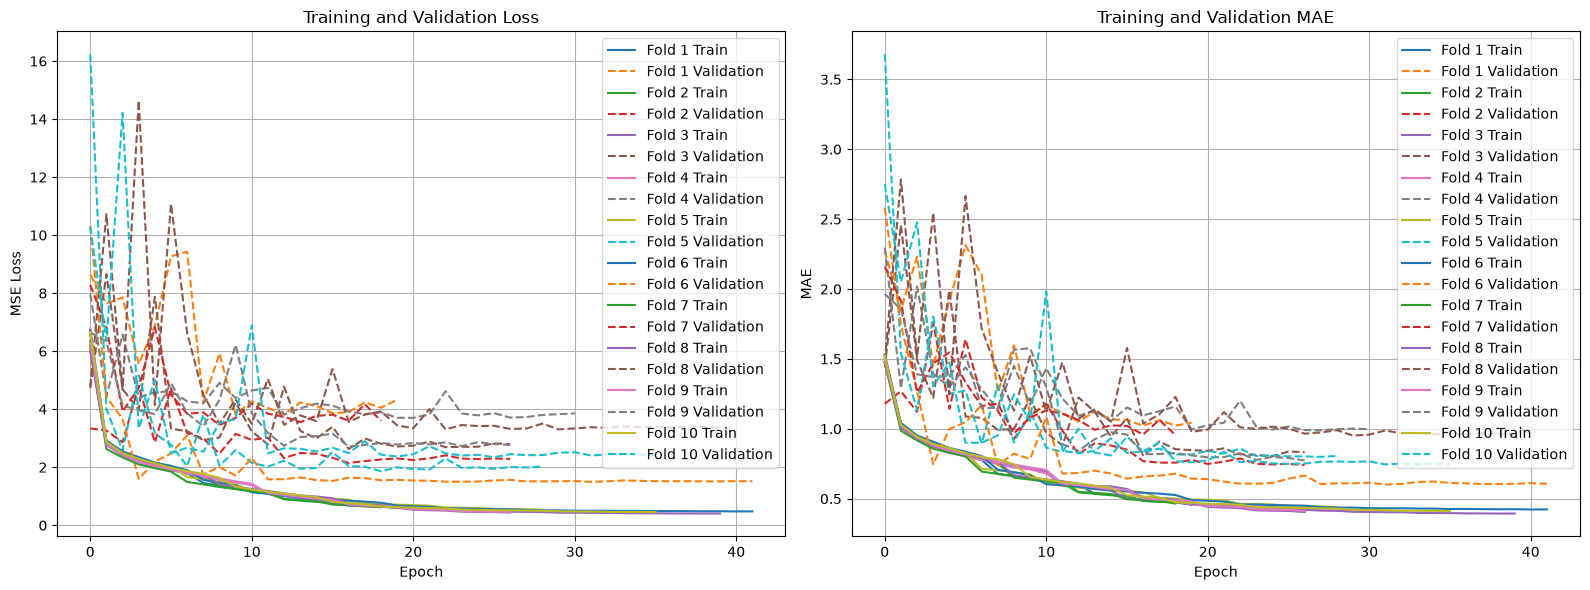

In [27]:
fig, axarr = plt.subplots(1, 2, figsize=(16, 6))


# TRAINING & VALIDATION LOSS

for fold in range(NUM_FOLDS):
    axarr[0].plot(train_loss_hist[fold], label=f"Fold {fold + 1} Train")

    axarr[0].plot(
        val_loss_hist[fold], linestyle="--", label=f"Fold {fold + 1} Validation"
    )

axarr[0].set_xlabel("Epoch")
axarr[0].set_ylabel("MSE Loss")
axarr[0].set_title("Training and Validation Loss")
axarr[0].legend()
axarr[0].grid(True)


# TRAINING & VALIDATION MAE

for fold in range(NUM_FOLDS):
    axarr[1].plot(train_mae_hist[fold], label=f"Fold {fold + 1} Train")

    axarr[1].plot(
        val_mae_hist[fold], linestyle="--", label=f"Fold {fold + 1} Validation"
    )

axarr[1].set_xlabel("Epoch")
axarr[1].set_ylabel("MAE")
axarr[1].set_title("Training and Validation MAE")
axarr[1].legend()
axarr[1].grid(True)


plt.tight_layout()
plt.show()

In [28]:
best_train_loss_mse = np.zeros(NUM_FOLDS)
best_val_loss_mse = np.zeros(NUM_FOLDS)

for i in range(NUM_FOLDS):
    best_val_loss_mse[i] = np.min(val_loss_hist[i])

    idx = np.argmin(val_loss_hist[i])
    best_train_loss_mse[i] = train_loss_hist[i][idx]

    print(
        f"Model {i + 1:02d} | "
        f"Train RMSE: {np.sqrt(best_train_loss_mse[i]):.3f} kW | "
        f"Val RMSE: {np.sqrt(best_val_loss_mse[i]):.3f} kW"
    )

print(f"Mean Train RMSE: " f"{np.mean(np.sqrt(best_train_loss_mse)):.3f} kW")
print(f"Mean Validation RMSE: " f"{np.mean(np.sqrt(best_val_loss_mse)):.3f} kW")

Model 01 | Train RMSE: 1.128 kW | Val RMSE: 1.955 kW
Model 02 | Train RMSE: 0.823 kW | Val RMSE: 1.466 kW
Model 03 | Train RMSE: 0.830 kW | Val RMSE: 1.621 kW
Model 04 | Train RMSE: 0.761 kW | Val RMSE: 1.924 kW
Model 05 | Train RMSE: 0.857 kW | Val RMSE: 1.365 kW
Model 06 | Train RMSE: 0.707 kW | Val RMSE: 1.224 kW
Model 07 | Train RMSE: 1.149 kW | Val RMSE: 1.859 kW
Model 08 | Train RMSE: 0.660 kW | Val RMSE: 1.818 kW
Model 09 | Train RMSE: 0.847 kW | Val RMSE: 1.649 kW
Model 10 | Train RMSE: 0.721 kW | Val RMSE: 1.531 kW
Mean Train RMSE: 0.848 kW
Mean Validation RMSE: 1.641 kW


In [29]:
predictions = np.zeros((NUM_FOLDS, len(X_test)), dtype=np.float32)

# Build streaming test dataset (batch_size=512 for fast evaluation)
ds_test = build_tf_dataset(
    X_test, y_test, np.arange(len(y_test)), batch_size=512, is_training=False
)

for fold in range(NUM_FOLDS):
    checkpoint_path = os.path.join(
        output_folder, f"repetition_{fold + 1}", f"best_model_repetition_{fold + 1}.h5"
    )

    print(f"Loading fold {fold + 1} model from: " f"{checkpoint_path}")

    try:
        fold_model = keras.models.load_model(checkpoint_path, compile=False)
    except Exception:
        fold_model = build_cnn_model(input_shape=(64, 64, 3))
        fold_model.load_weights(checkpoint_path)

    pred = fold_model.predict(ds_test, verbose=0)

    predictions[fold] = np.squeeze(pred)

# Save individual fold predictions
np.save(os.path.join(output_folder, "test_predictions_all_folds.npy"), predictions)

# Ensemble average
ensemble_predictions = np.mean(predictions, axis=0)

np.save(
    os.path.join(output_folder, "test_predictions_ensemble.npy"), ensemble_predictions
)

Loading fold 1 model from: model_output/CNN_nowcast_2017_2019_data/repetition_1/best_model_repetition_1.h5
Loading fold 2 model from: model_output/CNN_nowcast_2017_2019_data/repetition_2/best_model_repetition_2.h5
Loading fold 3 model from: model_output/CNN_nowcast_2017_2019_data/repetition_3/best_model_repetition_3.h5
Loading fold 4 model from: model_output/CNN_nowcast_2017_2019_data/repetition_4/best_model_repetition_4.h5
Loading fold 5 model from: model_output/CNN_nowcast_2017_2019_data/repetition_5/best_model_repetition_5.h5
Loading fold 6 model from: model_output/CNN_nowcast_2017_2019_data/repetition_6/best_model_repetition_6.h5
Loading fold 7 model from: model_output/CNN_nowcast_2017_2019_data/repetition_7/best_model_repetition_7.h5
Loading fold 8 model from: model_output/CNN_nowcast_2017_2019_data/repetition_8/best_model_repetition_8.h5
Loading fold 9 model from: model_output/CNN_nowcast_2017_2019_data/repetition_9/best_model_repetition_9.h5
Loading fold 10 model from: model_out

COMPLETE TEST SET NOWCAST RESULTS
Total Test Sequences: 13,683
Overall Test RMSE:    2.125 kW
Overall Test MAE:     1.096 kW


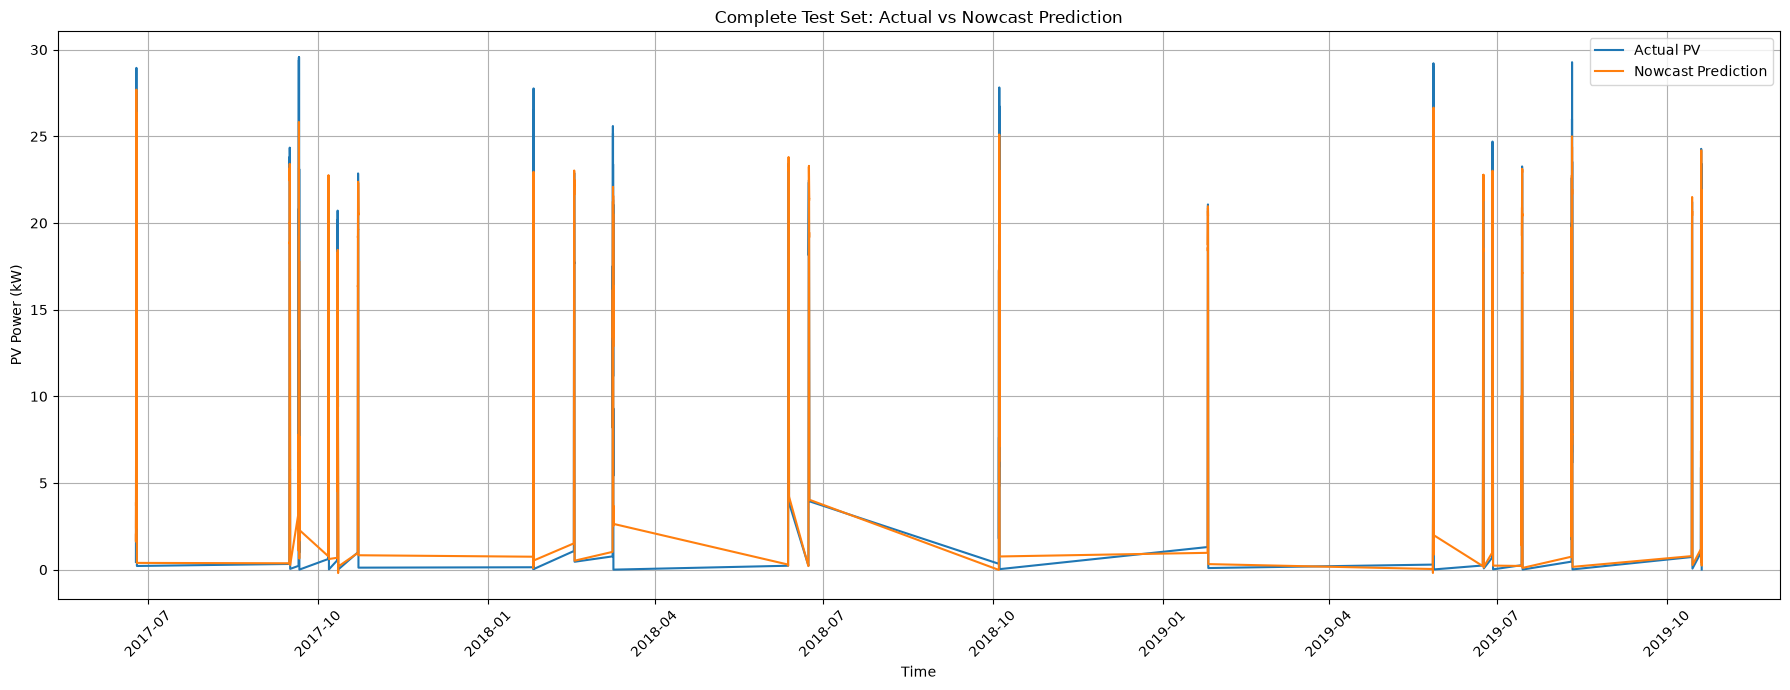

In [30]:
# TEST SET EVALUATION

# Calculate prediction errors
errors = ensemble_predictions - y_test

# RMSE
rmse_overall = np.sqrt(np.mean(np.square(errors)))

# MAE
mae_overall = np.mean(np.abs(errors))

print("COMPLETE TEST SET NOWCAST RESULTS")

print(f"Total Test Sequences: {len(y_test):,}")
print(f"Overall Test RMSE:    {rmse_overall:.3f} kW")
print(f"Overall Test MAE:     {mae_overall:.3f} kW")


# TIME-SERIES PLOT

plt.figure(figsize=(18, 7))

plt.plot(times_test_seq, y_test, label="Actual PV")

plt.plot(times_test_seq, ensemble_predictions, label="Nowcast Prediction")

plt.xlabel("Time")
plt.ylabel("PV Power (kW)")
plt.title("Complete Test Set: Actual vs Nowcast Prediction")

plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [31]:
# SUNNY AND CLOUD DATES FROM THE SKIPP'D PAPER

sunny_dates = [
    (2017, 9, 15),
    (2017, 10, 6),
    (2017, 10, 22),
    (2018, 2, 16),
    (2018, 6, 12),
    (2018, 6, 23),
    (2019, 1, 25),
    (2019, 6, 23),
    (2019, 7, 14),
    (2019, 10, 14),
]

cloudy_dates = [
    (2017, 6, 24),
    (2017, 9, 20),
    (2017, 10, 11),
    (2018, 1, 25),
    (2018, 3, 9),
    (2018, 10, 4),
    (2019, 5, 27),
    (2019, 6, 28),
    (2019, 8, 10),
    (2019, 10, 19),
]

sunny_dates_test = [datetime.date(y, m, d) for y, m, d in sunny_dates]

cloudy_dates_test = [datetime.date(y, m, d) for y, m, d in cloudy_dates]

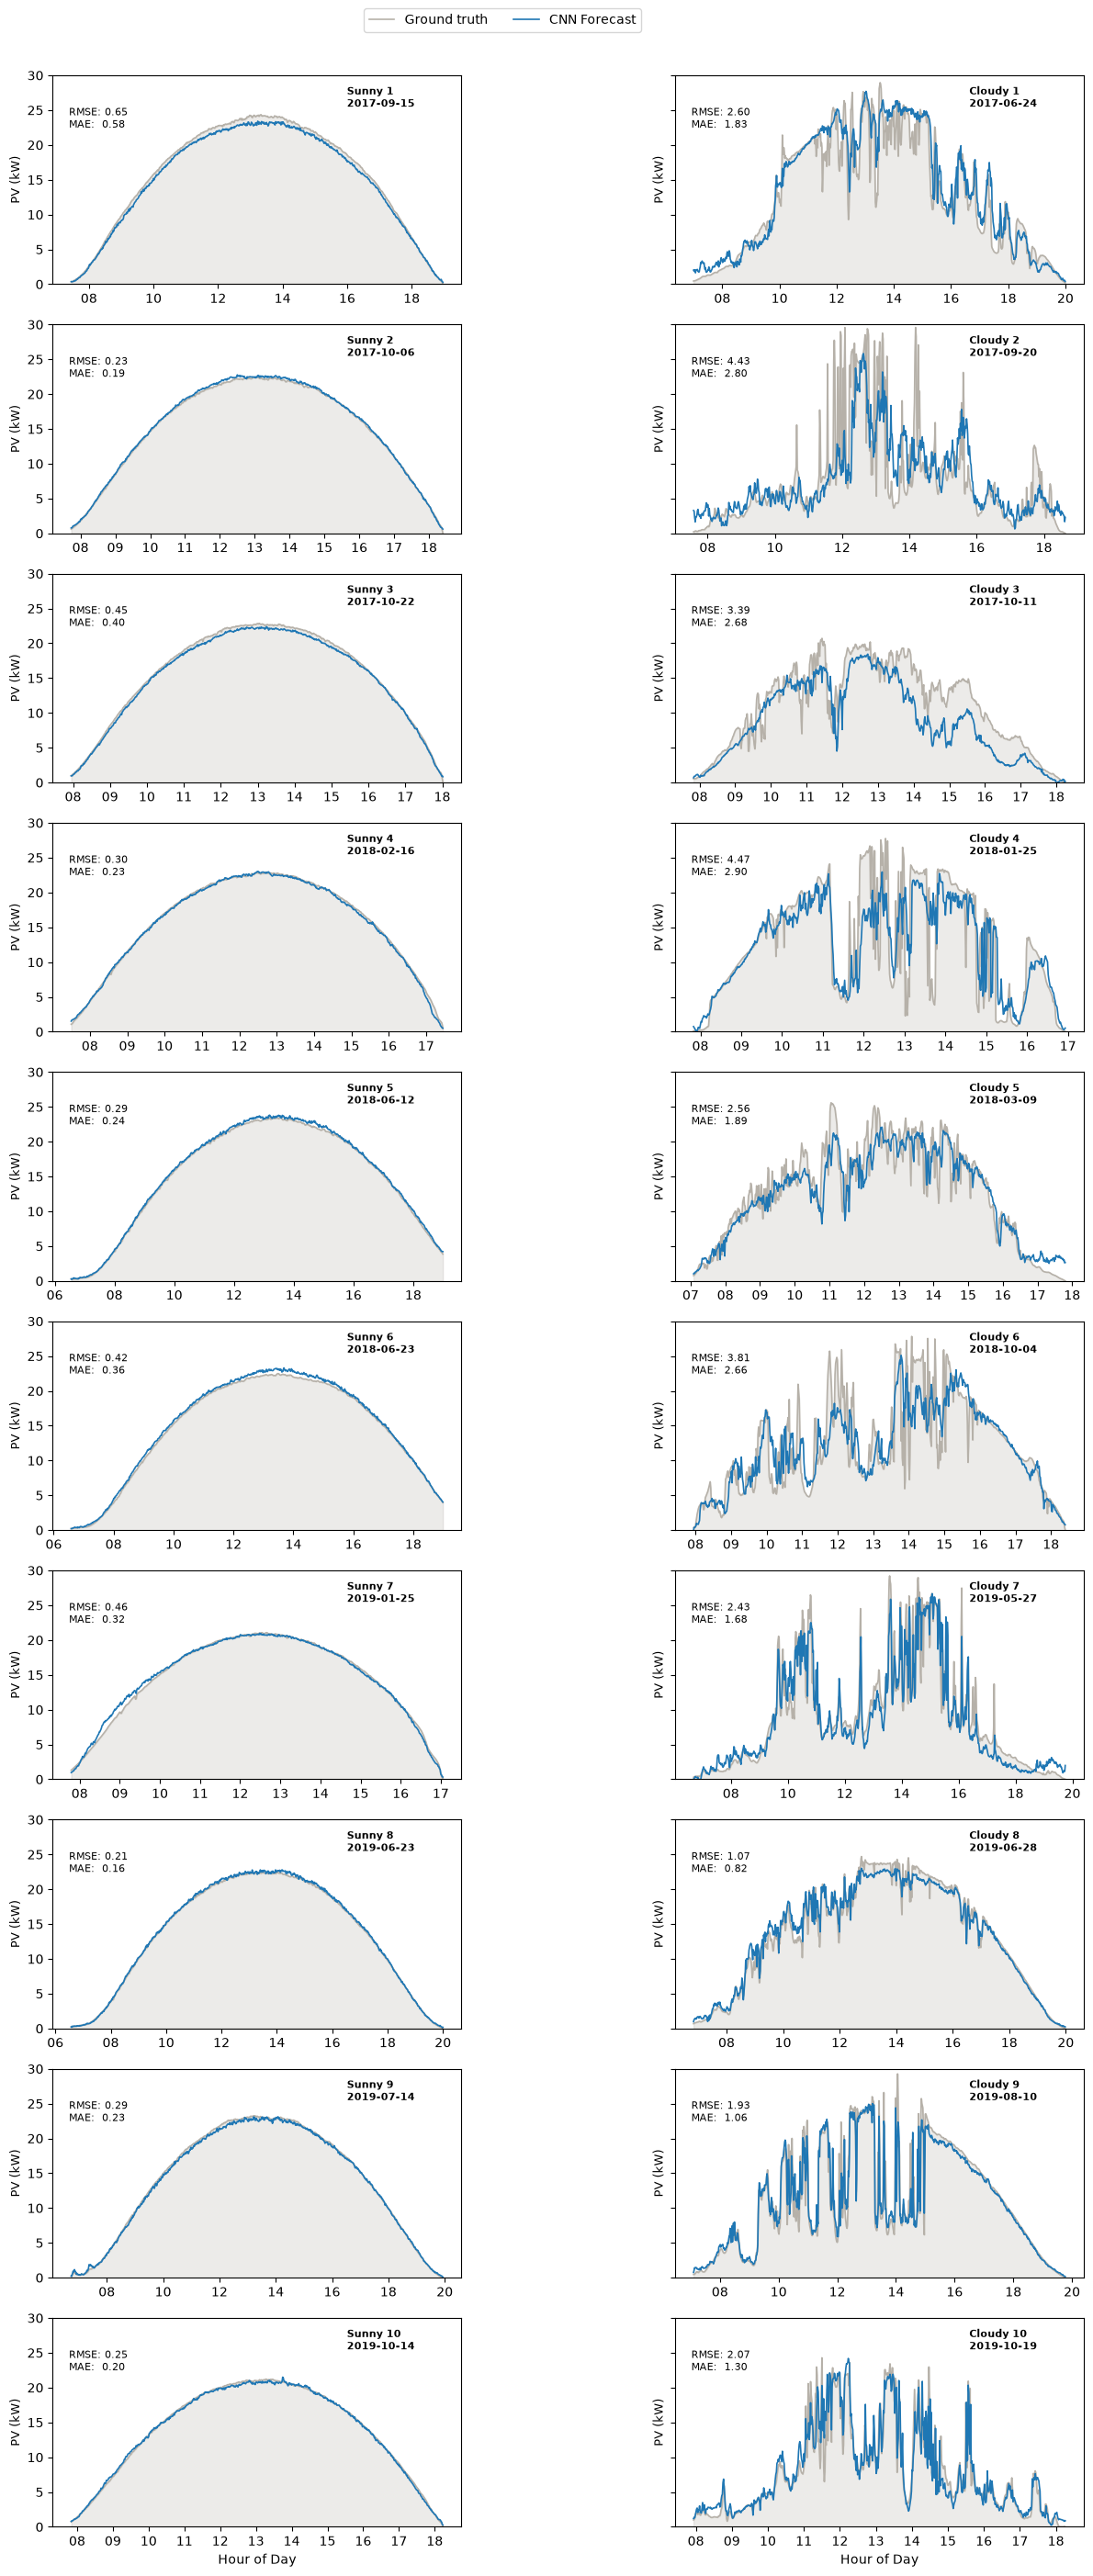

In [32]:
hours_test_seq = np.array(
    [
        (
            t.time()
            if isinstance(t, (datetime.datetime, datetime.time))
            else pd.to_datetime(t).time()
        )
        for t in times_test_seq
    ]
)

fig, axarr = plt.subplots(10, 2, sharex=False, sharey=True, figsize=(12, 28))

xfmt = mdates.DateFormatter("%H")
fmt_date = datetime.date(2000, 1, 1)

COLOR_GT = "#B6B1A9"
COLOR_PRED = "#1f77b4"


# Plot Sunny Days
for i, date in enumerate(sunny_dates_test):
    ax = axarr[i, 0]
    date_mask = dates_test_seq == date

    hours_xaxis = [
        datetime.datetime.combine(fmt_date, h) for h in hours_test_seq[date_mask]
    ]

    y_true_d = y_test[date_mask]
    y_pred_d = ensemble_predictions[date_mask]

    d_rmse = np.sqrt(np.mean(np.square(y_true_d - y_pred_d)))
    d_mae = np.mean(np.abs(y_true_d - y_pred_d))

    ax.plot(
        hours_xaxis,
        y_true_d,
        color=COLOR_GT,
        linewidth=1.2,
        label="Ground truth" if i == 0 else "",
    )

    ax.fill_between(hours_xaxis, 0, y_true_d, color=COLOR_GT, alpha=0.25)

    ax.plot(
        hours_xaxis,
        y_pred_d,
        color=COLOR_PRED,
        linewidth=1.2,
        label="CNN Forecast" if i == 0 else "",
    )

    ax.set_ylabel("PV (kW)", fontsize=9)
    ax.xaxis.set_major_formatter(xfmt)

    ax.text(
        0.72,
        0.85,
        f"Sunny {i + 1}\n{date}",
        transform=ax.transAxes,
        fontsize=8,
        fontweight="bold",
    )

    ax.text(
        0.04,
        0.75,
        f"RMSE: {d_rmse:.2f}\nMAE:  {d_mae:.2f}",
        transform=ax.transAxes,
        fontsize=8,
    )


# Plot Cloudy Days
for i, date in enumerate(cloudy_dates_test):
    ax = axarr[i, 1]
    date_mask = dates_test_seq == date

    hours_xaxis = [
        datetime.datetime.combine(fmt_date, h) for h in hours_test_seq[date_mask]
    ]

    y_true_d = y_test[date_mask]
    y_pred_d = ensemble_predictions[date_mask]

    d_rmse = np.sqrt(np.mean(np.square(y_true_d - y_pred_d)))
    d_mae = np.mean(np.abs(y_true_d - y_pred_d))

    ax.plot(hours_xaxis, y_true_d, color=COLOR_GT, linewidth=1.2)

    ax.fill_between(hours_xaxis, 0, y_true_d, color=COLOR_GT, alpha=0.25)

    ax.plot(hours_xaxis, y_pred_d, color=COLOR_PRED, linewidth=1.2)

    ax.set_ylabel("PV (kW)", fontsize=9)
    ax.xaxis.set_major_formatter(xfmt)

    ax.text(
        0.72,
        0.85,
        f"Cloudy {i + 1}\n{date}",
        transform=ax.transAxes,
        fontsize=8,
        fontweight="bold",
    )

    ax.text(
        0.04,
        0.75,
        f"RMSE: {d_rmse:.2f}\nMAE:  {d_mae:.2f}",
        transform=ax.transAxes,
        fontsize=8,
    )


axarr[0, 0].set_ylim(0, 30)

axarr[0, 0].legend(bbox_to_anchor=[1.1, 1.35], loc="upper center", ncol=2, frameon=True)

axarr[-1, 0].set_xlabel("Hour of Day", fontsize=10)
axarr[-1, 1].set_xlabel("Hour of Day", fontsize=10)

plt.tight_layout()

plt.show()

In [33]:
%load_ext tensorboard
%tensorboard --logdir {tensorboard_root}

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 155772), started 0:19:06 ago. (Use '!kill 155772' to kill it.)